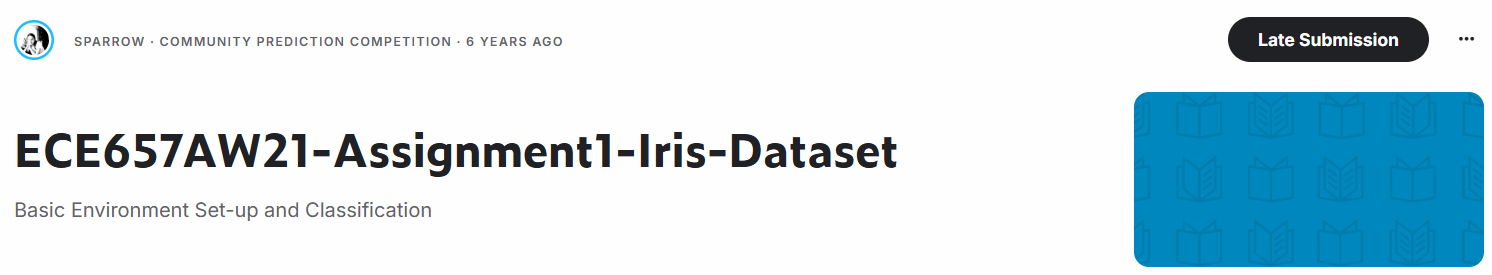
* kaggle : https://www.kaggle.com/competitions/ece657aw21-assignment1-iris-dataset

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Ft98JC%2Fbtsa6CuL7nS%2FAAAAAAAAAAAAAAAAAAAAAK32wdgXML8riDq-x9JGCuY2AwTjYVYT8-E5c199JyIX%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZedzHcoQWPMtOO8mzu493Vm48Y8%253D" width=400>

<pre>Id
SepalLengthCm
SepalWidthCm
PetalLengthCm
PetalWidthCm
Species

In [42]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split           #---- 문제답 분리


from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score

from sklearn.linear_model import LogisticRegression             #---- 분류모델(선형모델)
from sklearn.ensemble import RandomForestClassifier             #---- 분류모델(트리모델)   
from sklearn.ensemble import VotingClassifier, VotingRegressor  #---- 분류모델(앙상블)  

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score #---- 평가 메트릭스
from sklearn.metrics import roc_auc_score, roc_curve     #---- 평가 메트릭스
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate  #----교차검증

from sklearn.preprocessing import LabelEncoder, OneHotEncoder                       #-----인코딩(글자->숫자변경)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler        #-----정규화(스케일링)
from sklearn.decomposition import PCA                                               #-----차원축소


# **[1] Data Load : Toy DataSet**
* https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris
* 0 : setosa,  1 : versicolor , 2 : virginica

In [43]:
from sklearn.datasets import load_iris
tupl = load_iris(return_X_y=True, as_frame=True)
df = tupl[0]
df['target'] = tupl[1]

In [44]:
df = df.rename(columns={'sepal length (cm)':'sl',
                      'sepal width (cm)' : 'sw',
                      'petal length (cm)': 'pl',
                      'petal width (cm)' : 'pw'
                     })

In [45]:
df.head(2)

,sl,sw,pl,pw,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [46]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sl      150 non-null    float64
 1   sw      150 non-null    float64
 2   pl      150 non-null    float64
 3   pw      150 non-null    float64
 4   target  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


# **[2] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도(왜도,첨도,정규분포)

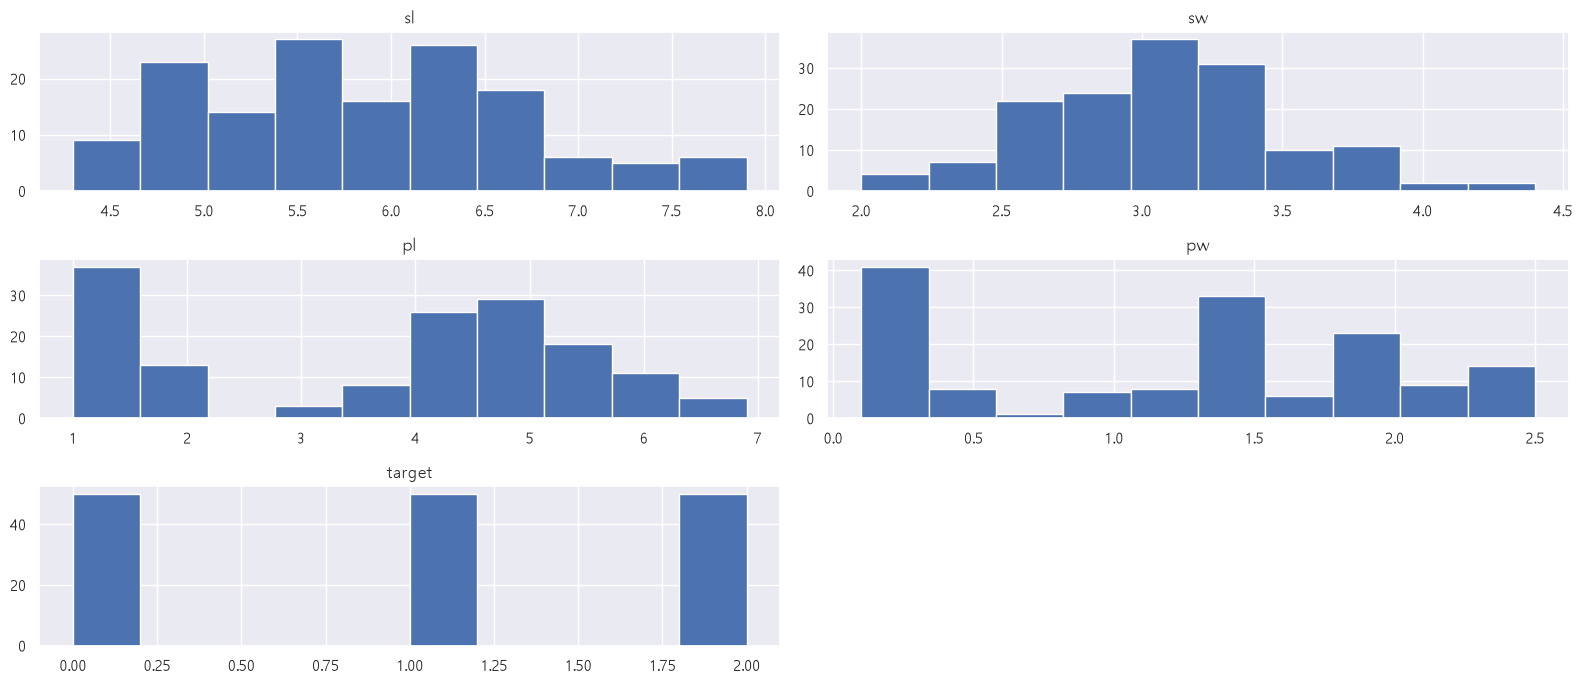

In [48]:
df.hist(figsize=(16,7))
plt.tight_layout()
plt.show()

## pairplot : hist + scatter

<Figure size 1000x400 with 0 Axes>

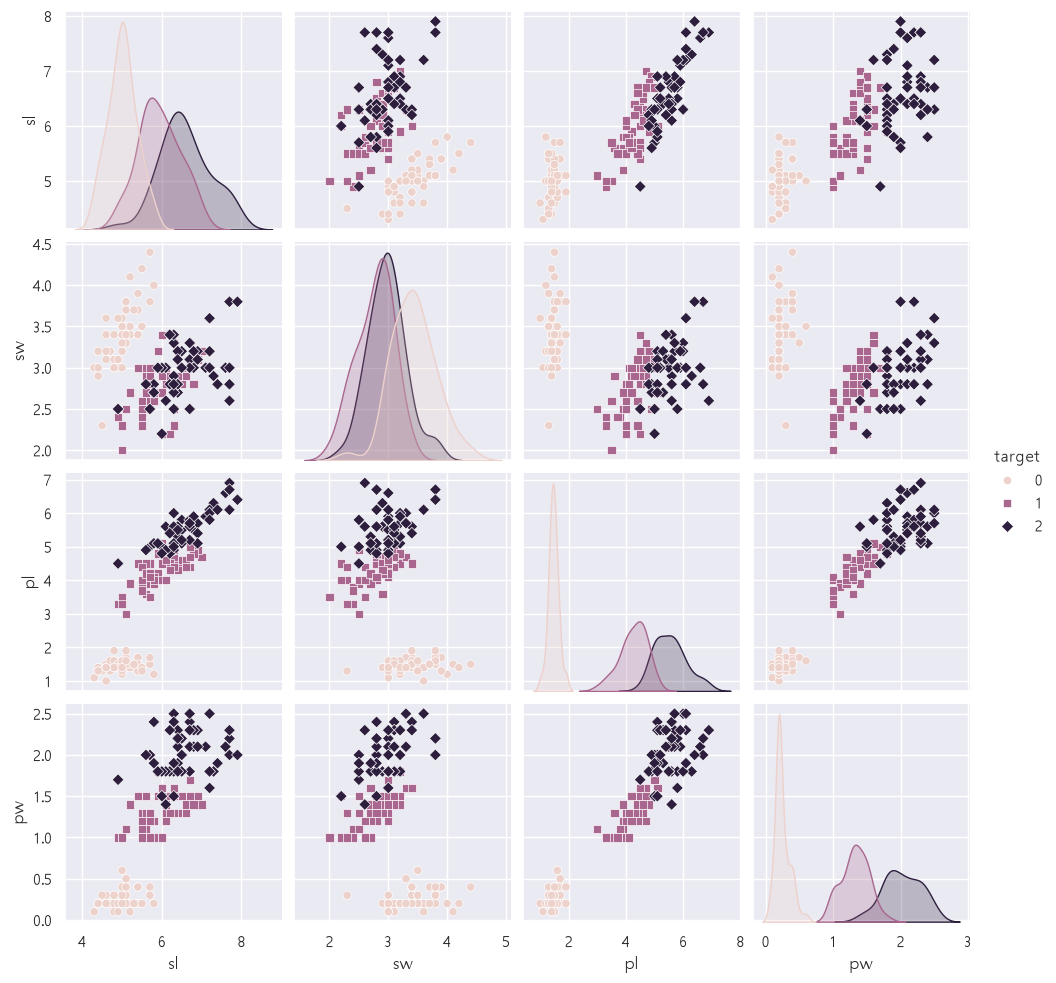

In [49]:
plt.figure(figsize=(10,4))
sns.pairplot(
    data=df,
    hue="target",     
    kind="scatter",    # 비대각선에 그릴 그래프 형태 ('scatter', 'kde', 'hist', 'reg')
    diag_kind="auto",  # 대각선에 그릴 그래프 형태 ('auto', 'hist', 'kde', None)
    markers=["o", "s", "D"],  # 클래스별 마커 모양 차별화
    )
plt.show()

## **상관분석**

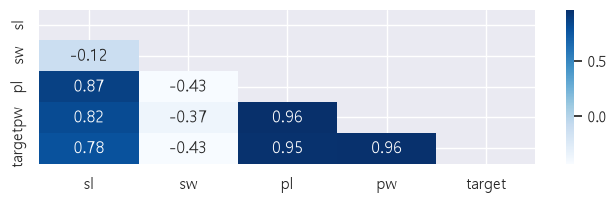

In [50]:
plt.figure(figsize=(8, 2))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(method='pearson'), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

* p : pw , pl
* s : sl , sw

* <font color=red><b>결측없다
* <font color=red><b>글자없다

# **[3] 다중 분류**

## **공통함수**

* **Macro 평균**
    - 각 클래스의 점수를 각각 계산한 후 평균 냄
    - 모든 클래스를 동일한 비중으로 평가
* **Micro 평균**
    - 모든 클래스의 값을 모두 합친 후 평균 냄
    - 샘플 수가 많은 클래스의 영향이 큼
---
* **OvO (One-vs-One, 일대일 방식)**
    - 가능한 모든 클래스의 조합 쌍을 만들어 1:1로 비교
* **OvR (One-vs-Rest / One-vs-All, 일대다 방식)**
    - 특정 클래스 하나와 나머지 클래스 전체를 비교

In [51]:
def myscore333(df,  model=None, MY_TARGET="target") :
    X = df.drop(columns=['target'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3
                                                                , random_state=1234, shuffle=True,  stratify=y)
    if model is None : 
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred, average='macro')
    precision = precision_score(y_test3, pred, average='macro')
    recall    = recall_score(y_test3, pred, average='macro')  
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )

    cr = classification_report(y_test3, pred)
    print(cr)


    #-------------------------------------------------proba
    proba = model.predict_proba(X_test3)
    roc = roc_auc_score(y_test3, proba, average='macro', multi_class='ovr')
    print( f"roc auc score : {roc:.4f}" )
    
    fpr = {}
    tpr = {}
    thresh ={}
    
    n_class = 3
    for i in range(n_class):    
        fpr[i], tpr[i], thresh[i] = roc_curve(y_test3, proba[:,i], pos_label=i)
        
    # plotting    
    plt.figure(figsize=(8,2))
    plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='Class 0 vs Rest')
    plt.plot(fpr[1], tpr[1], linestyle='--',color='green' , label='Class 1 vs Rest')
    plt.plot(fpr[2], tpr[2], linestyle='--',color='blue'  , label='Class 2 vs Rest')
    plt.plot([0, 1], [0, 1], 'k-')
    plt.title("roc_curve")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR) == recall")
    plt.legend()
    plt.show()

    
    return model

## **점수확인**

RandomForestClassifier
acc : 0.9556  f1 : 0.9556  precision : 0.9556  recall : 0.9556
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

roc auc score : 0.9956


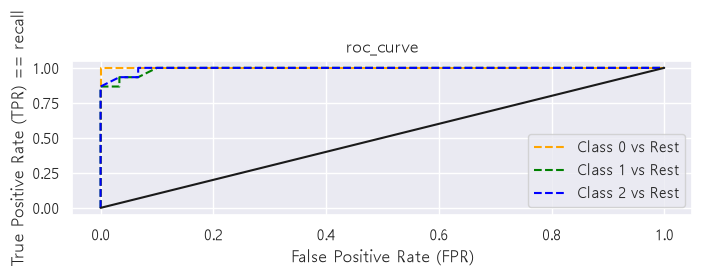

In [52]:
model = myscore333(df)

# **[4] 군집 분석**

``` python
class sklearn.cluster.KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
    
class sklearn.metrics.silhouette_samples(X, labels, *, metric='euclidean', **kwds)

class sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)


## **답지(label) 없음**

In [53]:
df.columns

Index(['sl', 'sw', 'pl', 'pw', 'target'], dtype='str')

In [54]:
X = df[['sl', 'sw', 'pl', 'pw']]

## **[4-1] KMeans**
* K = Cluster Center 갯수
* node = 점
* samples = 모든 점

<img src="https://miro.medium.com/v2/resize:fit:875/0*8ERlq_ZmWnZzDO83.gif" width=300>

### K=3

In [55]:
kmodel = KMeans(n_clusters=3, random_state=1234)
kmodel.fit(X)
pred_label = kmodel.predict(X)
print(pred_label)

ch = kmodel.cluster_centers_
print(ch)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]
[[5.006      3.428      1.462      0.246     ]
 [6.85384615 3.07692308 5.71538462 2.05384615]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [56]:
df['pred_label'] = pred_label
df.head(2)

,sl,sw,pl,pw,target,pred_label
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0


* **K=3인 경우 헤더들**
* 150건 전체 레코드 중 데이터

In [57]:
ch_df = pd.DataFrame(ch, columns=['sx','sy','px','py'])
ch_df.head()

,sx,sy,px,py
0,5.006000,3.428000,1.462000,0.246000
1,6.853846,3.076923,5.715385,2.053846
2,5.883607,2.740984,4.388525,1.434426


* **sl/sw**

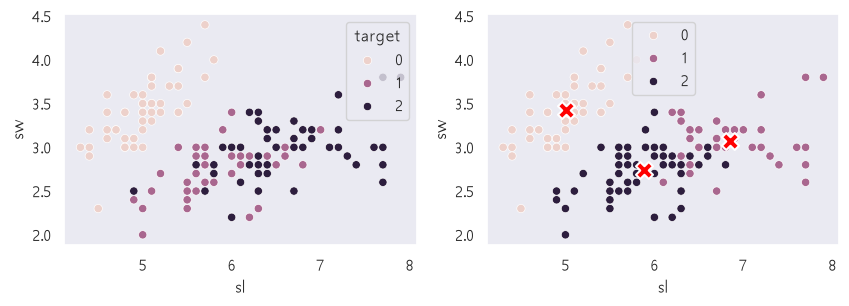

In [58]:
p, axes = plt.subplots(1,2, figsize=(10,3))
sns.scatterplot(data=df, x="sl", y="sw", hue="target", ax=axes[0])

sns.scatterplot(data=df, x="sl", y="sw", hue="pred_label", ax=axes[1])
sns.scatterplot(data=ch_df, x='sx', y='sy', ax=axes[1]
               , marker="X", s=150,  color="red", linewidth=1.5)  #---CH위치
axes[0].grid(False)
axes[1].grid(False)
plt.show()

* **pl/pw**

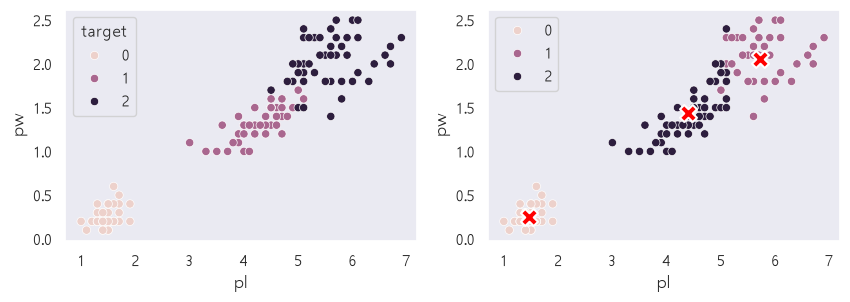

In [59]:
p, axes = plt.subplots(1,2, figsize=(10,3))
sns.scatterplot(data=df, x="pl", y="pw", hue="target", ax=axes[0])

sns.scatterplot(data=df, x="pl", y="pw", hue="pred_label", ax=axes[1])
sns.scatterplot(data=ch_df, x='px', y='py', ax=axes[1]
               , marker="X", s=150,  color="red", linewidth=1.5)  #---CH위치
axes[0].grid(False)
axes[1].grid(False)
plt.show()

### K값 튜닝

* **inertia_** : CH와 CH 주변의 모든 점들의 거리 제곱 합
    - Sum of squared distances of samples to their closest cluster center
    - 응집도가 높다(주변 점들이 밀집되있다)
    - 작을 수록 좋다

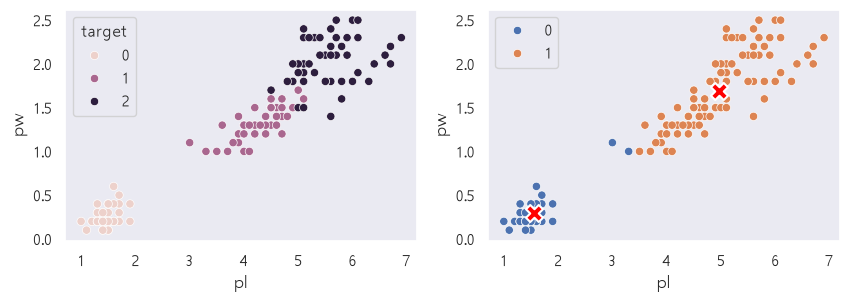

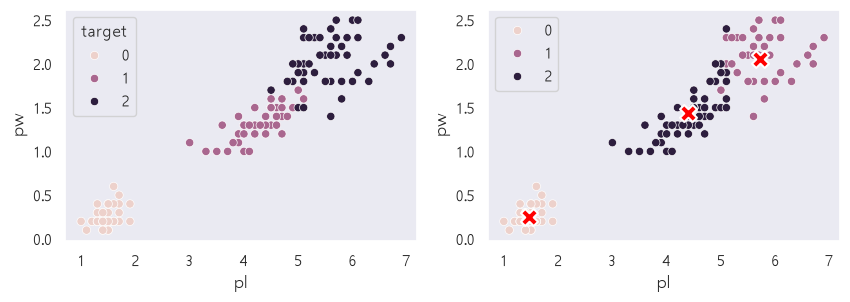

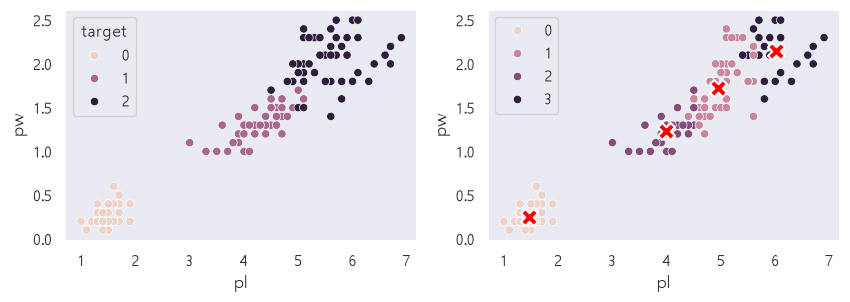

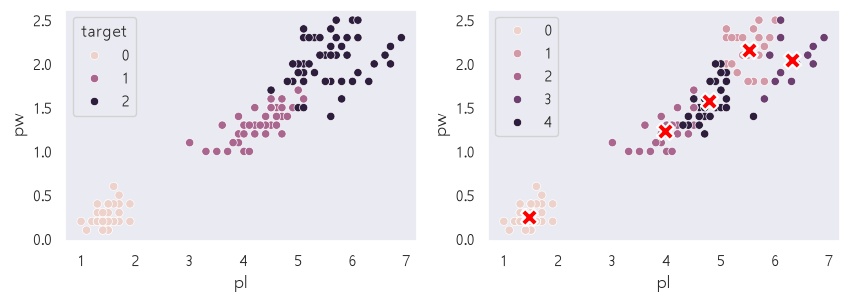

In [60]:
inertia_list = []
for MY_K in  [2,3,4,5] :
    kmodel = KMeans(n_clusters=MY_K, random_state=1234)
    kmodel.fit(X)
    pred_label = kmodel.predict(X)

    inertia_list.append(kmodel.inertia_)
    
    ch = kmodel.cluster_centers_
    df['pred_label'] = pred_label
    ch_df = pd.DataFrame(ch, columns=['sx','sy','px','py'])

    p, axes = plt.subplots(1,2, figsize=(10,3))
    sns.scatterplot(data=df, x="pl", y="pw", hue="target", ax=axes[0])
    
    sns.scatterplot(data=df, x="pl", y="pw", hue="pred_label", ax=axes[1])
    sns.scatterplot(data=ch_df, x='px', y='py', ax=axes[1]
                   , marker="X", s=150,  color="red", linewidth=1.5)  #---CH위치
    axes[0].grid(False)
    axes[1].grid(False)
    plt.show()   

### 적정 K(군집갯수) : 3개

In [ ]:
print(inertia_list)

plt.figure(figsize=(4,2))
plt.plot([2,3,4,5], inertia_list)
plt.title("엘보차트(적정K값)")
plt.show()

### Silhouette Coefficient / Silhouette Score
* **Coef계산하는 함수 : silhouette_samples()**
    - 모든 점들의 (b - a) / max(a, b) 계산하는 함수
    - silhouette_samples() 함수를 사용해 150개 점의 Silhouette Coefficient 계산
* **150개 : Silhouette Coefficient**
    - 모든 점들이 (b - a) / max(a, b) 계산
    - a : 내가 속한 클러스터 내부 평균 거리(mean intra-cluster distance)
    - b : 내가 속한 클러스터 헤더를 제외한 가장 가까운 헤더와의 거리
    - 1 : 최상
    - 0 : 겹쳐있음
    - -1 : 잘못된 군집
* **1개 평균값 : Silhouette Score**
    - 모든 점들의 Silhouette Coefficient 평균 값

``` python 
from sklearn.metrics import silhouette_samples, silhouette_score

class sklearn.metrics.silhouette_samples(X, labels, *, metric='euclidean', **kwds)

class sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)

In [ ]:
kmodel = KMeans(n_clusters=3, random_state=1234)
kmodel.fit(X)
pred_label = kmodel.predict(X)
df['pred_label'] = pred_label

* **방법1) scoef150 =silhouette_samples() 후 scoef150.mean()**

In [ ]:
scoef150 = silhouette_samples(df[['sl','sw','pl','pw']],  df['pred_label'])
print(scoef150[:10])

In [ ]:
df['scoef150'] = scoef150
df.head(2)

In [ ]:
print( np.mean(scoef150) )

* **방법2) silhouette_score()**

In [ ]:
sscore = silhouette_score(df[['sl','sw','pl','pw']],  df['pred_label'])
print(sscore)

### 군집별  silhouette_score
* groupby("pred_label")['scoef150'].mean()

In [ ]:
df.groupby("pred_label")['scoef150'].mean()

## **[4-2] 표준화(StandardScaler)**
* **Scaler** : StandardScaler,  MinMaxScaler, AbsoluteScaler
* StandardScaler(평균0, 편차1) == 표준정규분포 범위로 데이터 축소 == 표준화
* 연속형 피쳐에 주로 사용

In [ ]:
ss =  StandardScaler()
ss.fit(df[['sl','sw','pl','pw']])
scale_res = ss.transform(df[['sl','sw','pl','pw']])
scale_res[:3]

## **[4-3] PCA(Principal component analysis) : 주성분 분석**
* 공분산 행렬 내적 : 고유값(주성분), 고유벡터(PC)
    * PC1 == 1번째 고유벡터 == 고유값을 가장 많이 포함하는(분산 최대) 선
    * PC2 == 2번째 고유벡터 ==  PC1과 직교
    * PCn == n번째 고유벡터 ==  PC(n-1)과 직교
* 고유값(주성분) 분석
    - 원하는 설명력(explained_variance_)을 가지려면 몇 차까지 축소??

<img src="https://i.imgur.com/Uv2dlsH.gif" width=600>

``` python
class sklearn.decomposition.PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)

### **PCA**

In [ ]:
df[['sl','sw','pl','pw']].head(3)

In [ ]:
pca = PCA(n_components=2, random_state=1234)
pca_res = pca.fit_transform(df[['sl','sw','pl','pw']])
pca_res[:3]

In [ ]:
#pca.explained_variance_
print( f"각각의 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

### **표준화 적용하지않은 PCA**

In [ ]:
pca = PCA(n_components=2, random_state=1234)
pca_res = pca.fit_transform(df[['sl','sw','pl','pw']])
print(pca_res[:3])
print( f"각각의 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

plt.figure(figsize=(4,2))
plt.scatter(x=pca_res[:, 0] , y=pca_res[:, 1] )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("표준화 전 PCA")
plt.show()

### **표준화 적용한 PCA**

In [ ]:
ss =  StandardScaler()
ss.fit(df[['sl','sw','pl','pw']])
scale_res = ss.transform(df[['sl','sw','pl','pw']])
scale_res[:3]

pca = PCA(n_components=2, random_state=1234)
pca_res = pca.fit_transform( scale_res)   ###df[['sl','sw','pl','pw']])
print(pca_res[:3])
print( f"각각의 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )   
# 시가화에 사용할 데이터 : x=pca_res[:, 0] , y=pca_res[:, 1]

plt.figure(figsize=(4,2))
plt.scatter(x=pca_res[:, 0] , y=pca_res[:, 1] )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("표준화 후 PCA")
plt.show()

## **[4-4] 평가 시각화 공통 함수**

In [ ]:
import matplotlib.cm as cm

def view_chart(X,range_n_clusters=[2, 3, 4, 5, 6]):
    for n_clusters in range_n_clusters:
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(14, 4)

        # --------선택적 : X = df[['sl','sw','pl','pw']] --------------
        ss =  StandardScaler()
        ss.fit(df[['sl','sw','pl','pw']])
        scale_res = ss.transform(df[['sl','sw','pl','pw']])
        
        pca = PCA(n_components=2, random_state=1234)
        pca_res = pca.fit_transform( scale_res)   ###df[['sl','sw','pl','pw']])
        print( f"각각의 PC 설명력 : {pca.explained_variance_ratio_}" )
        print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )   
        # 시가화에 사용할 데이터 : x=pca_res[:, 0] , y=pca_res[:, 1]
        X = pd.DataFrame(pca_res, columns=["sPC1","sPC2"])
        # -----------------------------------------------------------
       
        clusterer = KMeans(n_clusters=n_clusters, random_state=10)
       
        cluster_labels = clusterer.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            "For n_clusters =", n_clusters,
            "The average silhouette_score is :",silhouette_avg,
        )

        # ------------------ 차트 -------------------------
        sample_silhouette_values = silhouette_samples(X, cluster_labels)
        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            X.iloc[:, 0], X.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.show()

In [ ]:
view_chart(df[['sl','sw','pl','pw']], range_n_clusters=[2, 3, 4, 5])

## **[4-5] DBSCAN** ##
* DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
     -  핵심점 (Core Point): 반경(Epsilon, ε) 내에 지정된 최소 점 개수(MinPts) 이상의 이웃이 있는 점
     - 경계점(Border Point): 핵심점의 반경 내에 있지만, 자기 자신의 반경 내의 점 개수는 기준에 못 미치는 점
     - 잡음점(Noise Point): 핵심점도 아니고 경계점도 아닌 이상치

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250912174514326431/4.webp" width="600">

```python
class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean',
                             metric_params=None, algorithm='auto', 
                             leaf_size=30, p=None, n_jobs=None)[source]


In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
view_chart(df[['sl','sw','pl','pw']], range_n_clusters=[2, 3, 4, 5], model = dbscan)
